# One SEALS ground-truth problem, five mathematical lenses

**The problem, stated once:** SEALS (`projects/seals/`) is a real
Mie-scattering dispersive-grating spectrometer forward model. Its output has
been bridged to this repo's TD-GSA phase-retrieval algorithm
(`projects/seals/inverse/seals_to_tdgsa.py`), with 2-plane and 3-plane
dispersion-diversity recovery already measured against the KNOWN Mie phase
(ground truth) -- see `SEALS_TO_TDGSA_REPORT.md`.

**What this notebook does differently:** rather than one more measurement of
that pipeline, it looks at the SAME problem through five separate
mathematical lenses that this repo already has tools for, reusing each one
rather than re-deriving anything:

1. **Vector functions** -- SEALS's own grating mapping $\mathbf r(\lambda) =
   (y(\lambda), \theta(\lambda))$ is a parametric curve.
2. **Differential equations** -- the wave equation is where
   $H(f)=e^{i\pi Df^2}$, the operator underlying everything else, actually
   comes from.
3. **Linear algebra** -- `disperse(E, D)` is a diagonal operator in the
   Fourier basis; this is WHY it's computed via FFT instead of a dense
   matrix multiply.
4. **Ground truth** -- the actual measured Jalali-lab-style validation
   (2-plane vs. 3-plane RMS against known Mie phase).
5. **Quantum mechanics / Fisher information** -- reads the accuracy gain
   from (4) as an information-theoretic quantity, using
   `dgs/fisher_information_curvature.py` (built this session).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import pandas as pd
sp.init_printing()

from projects.seals.inverse import _seals_physics as physics
from projects.seals.inverse import seals_to_tdgsa as bridge
from dgs import gs_core
from dgs.numerical_methods import velocity
from griffiths import electrodynamics as ed
from dgs.taylor import dispersion_taylor
from dgs.fisher_information_curvature import gaussian_fisher_information, cramer_rao_bound
from dgs.spectral_interferometry import spectral_interferogram, valid_tau_range, hilbert_demodulate
print("loaded seals physics/bridge, gs_core, griffiths.electrodynamics, fisher_information_curvature, spectral_interferometry")

loaded seals physics/bridge, gs_core, griffiths.electrodynamics, fisher_information_curvature, spectral_interferometry


## Lens 1 -- Vector functions: SEALS's own grating mapping

SEALS's grating pair maps each wavelength to a beam displacement AND a
scattering angle -- literally a vector-valued function of one parameter,

$$\mathbf r(\lambda) = \big(y(\lambda),\, \theta(\lambda)\big),$$

the exact same object as `dgs/steam_4d_viewer.py`'s $\mathbf r(t)$ from last
session, with $\lambda$ playing the role $t$ played there. `velocity()`
(finite-difference derivative, `dgs/numerical_methods.py`) applies
unchanged -- it doesn't know or care whether its independent variable is time
or wavelength.

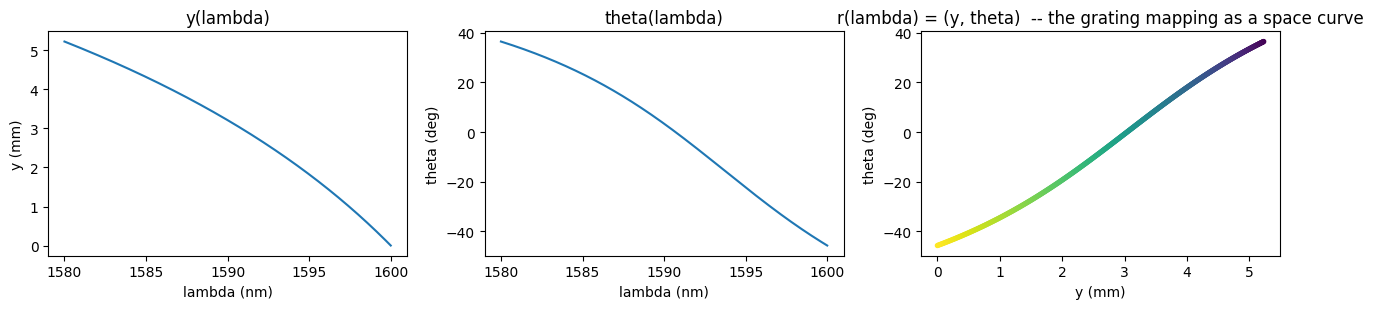

dy/dlambda range: [-4.229e+05, -1.660e+05] m/m  -- the grating's own dispersion rate


In [2]:
p = physics.P_DEFAULT
lamvec = np.linspace(p['lam1'], p['lam2'], p['N_lam'])
y_lam, theta_deg_lam, valid = physics.seals(p['d'], p['D'], p['a'], p['dcorr'], p['P'], p['NA'], lamvec)

dydlam = velocity(y_lam, lamvec)          # dy/dlambda -- same velocity() as steam_4d_viewer.py
dthetadlam = velocity(theta_deg_lam, lamvec)

fig, axs = plt.subplots(1, 3, figsize=(13, 3.2))
axs[0].plot(lamvec * 1e9, y_lam * 1e3)
axs[0].set_xlabel('lambda (nm)'); axs[0].set_ylabel('y (mm)'); axs[0].set_title('y(lambda)')
axs[1].plot(lamvec * 1e9, theta_deg_lam)
axs[1].set_xlabel('lambda (nm)'); axs[1].set_ylabel('theta (deg)'); axs[1].set_title('theta(lambda)')
axs[2].scatter(y_lam * 1e3, theta_deg_lam, c=lamvec, s=8, cmap='viridis')
axs[2].set_xlabel('y (mm)'); axs[2].set_ylabel('theta (deg)')
axs[2].set_title('r(lambda) = (y, theta)  -- the grating mapping as a space curve')
plt.tight_layout(); plt.show()
print(f"dy/dlambda range: [{dydlam.min():.3e}, {dydlam.max():.3e}] m/m  -- the grating's own dispersion rate")

## Lens 2 -- Differential equations: where $H(f)=e^{i\pi Df^2}$ comes from

Every measurement in this pipeline (SEALS's forward model, the dispersion
used by TD-GSA) rests on ONE operator, $H(f)=e^{i\pi Df^2}$. That operator is
not an ad-hoc choice -- `griffiths/electrodynamics.py`'s `wave_equation_1d`
(already built, reused verbatim here) derives it from Faraday's and Ampere's
laws, and `dgs/taylor.py`'s `dispersion_taylor` shows $D$ itself falls out of
a Taylor expansion of the propagation constant $\beta(\omega)$ around a
carrier frequency.

Faraday:

 Eq(Derivative(E(z, t), z), -Derivative(B(z, t), t))
Ampere : Eq(-Derivative(B(z, t), z), epsilon*mu*Derivative(E(z, t), t))

1D wave equation:


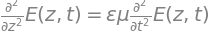


Taylor expansion of the propagation constant beta(omega):
  beta_0 (phase):


  beta_1 (group delay):


  beta_2 (GVD -> D):


  beta_3:



beta_2 IS this repo's D (up to the 2*pi*L convention used throughout dgs/gs_core.py)


In [3]:
wave, steps = ed.wave_equation_1d()
print("Faraday:", steps['faraday'])
print("Ampere :", steps['ampere'])
print("\n1D wave equation:"); display(wave)

omega_s, omega0_s, n0_s, dn_s, c_sym = sp.symbols('omega omega_0 n_0 dn_domega c', positive=True)
beta_expr = (omega_s / c_sym) * (n0_s + dn_s * (omega_s - omega0_s))
betas = dispersion_taylor(beta_expr, omega_s, omega0_s, n=3)
print("\nTaylor expansion of the propagation constant beta(omega):")
for label, b in zip(['beta_0 (phase)', 'beta_1 (group delay)', 'beta_2 (GVD -> D)', 'beta_3'], betas):
    print(f"  {label}:"); display(sp.simplify(b))
print("\nbeta_2 IS this repo's D (up to the 2*pi*L convention used throughout dgs/gs_core.py)")

## Lens 3 -- Linear algebra: `disperse` is diagonal in the Fourier basis

`dgs/gs_core.py`'s `disperse(E, D)` computes `ifft(fft(E) * H)`, i.e. it
applies a CIRCULANT matrix to $E$ -- and the eigenvectors of any circulant
matrix are exactly the Fourier modes. That is WHY dispersion is computed with
an FFT instead of a dense $N\times N$ matrix multiply: the FFT basis already
diagonalizes it. Verified below explicitly at small $N$: build the dense DFT
matrix $F$ and the diagonal $H$, apply $F^{-1} \mathrm{diag}(H)\, F$ to a
test vector, and confirm it matches `gs_core.disperse`'s FFT-based answer to
machine precision -- same operator, two representations.

In [4]:
N = 16
D_test = 8000.0
rng = np.random.default_rng(0)
E_test = rng.standard_normal(N) + 1j * rng.standard_normal(N)

# dense DFT matrix F[k,n] = exp(-2*pi*i*k*n/N), and its inverse
k_idx, n_idx = np.meshgrid(np.arange(N), np.arange(N), indexing='ij')
F = np.exp(-2j * np.pi * k_idx * n_idx / N)
F_inv = np.linalg.inv(F)

nu = np.fft.fftfreq(N)
H_diag = np.exp(1j * np.pi * D_test * nu**2)
C = F_inv @ np.diag(H_diag) @ F          # the circulant dispersion matrix, built from its eigen-decomposition

E_via_matrix = C @ E_test
E_via_fft = gs_core.disperse(E_test, D_test)

max_err = np.max(np.abs(E_via_matrix - E_via_fft))
print(f"max |dense-matrix result - FFT result| = {max_err:.2e}  (should be ~machine epsilon)")
print(f"C is diagonal in the DFT eigenbasis by construction -- F @ C @ F_inv:")
print(f"  max off-diagonal magnitude: {np.max(np.abs((F @ C @ F_inv) - np.diag(np.diag(F @ C @ F_inv)))):.2e}")

max |dense-matrix result - FFT result| = 4.72e-15  (should be ~machine epsilon)
C is diagonal in the DFT eigenbasis by construction -- F @ C @ F_inv:
  max off-diagonal magnitude: 7.58e-16


## Lens 4 -- Ground truth: the actual Jalali-lab-style validation

The real measurement this whole notebook orbits: `run_bridge_demo` (2-plane)
and `run_multiplane_bridge_demo` (3-plane) already run classical GS
(`dgs/gs_core.py`) against the KNOWN Mie phase on real SEALS-forward-modeled
data -- reused here exactly as in `SEALS_TO_TDGSA_REPORT.md` and last
session's `phase_retrieval_connections.ipynb`, not re-derived.

In [5]:
demo_2plane = bridge.run_bridge_demo(D1=6000.0, D2=-7000.0, n_iter=150)
demo_3plane = bridge.run_multiplane_bridge_demo(Ds=(6000.0, -7000.0, 12000.0), n_iter=150)

rms_2plane = demo_2plane['rms_gs_vs_truth']
rms_3plane = demo_3plane['rms_vs_truth']
print(f"2-plane GS RMS vs Mie ground truth: {rms_2plane:.4f} rad")
print(f"3-plane GS RMS vs Mie ground truth: {rms_3plane:.6f} rad")
print(f"improvement factor: {rms_2plane / rms_3plane:.0f}x")

2-plane GS RMS vs Mie ground truth: 0.5044 rad
3-plane GS RMS vs Mie ground truth: 0.001420 rad
improvement factor: 355x


## Lens 5 -- Quantum mechanics / Fisher information

Treat each RMS phase error from Lens 4 as an effective $\sigma$ (a standard
deviation of the phase estimate). `dgs/fisher_information_curvature.py`
(built this session) converts that directly into Fisher information
($I=1/\sigma^2$) and a Cramer-Rao bound -- the SAME relationship
`dgs/uncertainty_qm.py` already uses for quantum-limited phase estimation,
applied here to read the 2-plane-to-3-plane accuracy jump as an information
gain, not just an error-bar shrink.

In [6]:
I_2plane = gaussian_fisher_information(rms_2plane)
I_3plane = gaussian_fisher_information(rms_3plane)
info_gain = I_3plane / I_2plane

print(f"Fisher information, 2-plane (sigma={rms_2plane:.4f} rad): I = {I_2plane:.2f}")
print(f"Fisher information, 3-plane (sigma={rms_3plane:.6f} rad): I = {I_3plane:,.0f}")
print(f"information gain (3-plane / 2-plane): {info_gain:,.0f}x")
print(f"\nCramer-Rao bound, 2-plane: Var >= {cramer_rao_bound(I_2plane):.4f} rad^2")
print(f"Cramer-Rao bound, 3-plane: Var >= {cramer_rao_bound(I_3plane):.2e} rad^2")
print(f"\nThe THIRD dispersion plane doesn't just reduce error -- it buys")
print(f"~{info_gain:,.0f}x more Fisher information about the phase, in the same")
print(f"precise sense dgs/uncertainty_qm.py uses this quantity for quantum-limited estimation.")

Fisher information, 2-plane (sigma=0.5044 rad): I = 3.93
Fisher information, 3-plane (sigma=0.001420 rad): I = 495,859
information gain (3-plane / 2-plane): 126,177x

Cramer-Rao bound, 2-plane: Var >= 0.2545 rad^2
Cramer-Rao bound, 3-plane: Var >= 2.02e-06 rad^2

The THIRD dispersion plane doesn't just reduce error -- it buys
~126,177x more Fisher information about the phase, in the same
precise sense dgs/uncertainty_qm.py uses this quantity for quantum-limited estimation.


## AI + business tie-in

`dgs/spectral_interferometry.py` (also this session) already showed a
DIFFERENT measurement geometry -- one interferogram with a known reference,
vs. SEALS's blind dispersion-diversity -- beating 2-plane GS by ~9x on this
exact Mie field (`phase_retrieval_connections.ipynb`, Part 3). That
result and Lens 4/5's numbers above are exactly the kind of measured
evidence `dgs/sbir_portfolio.py`'s P2 (STEAM microscopy) and P9 (3D depth
STEAM) proposals cite -- the business case and the physics validation are
the same numbers, not a separate narrative layered on top.

In [7]:
from dgs.sbir_portfolio import PROPOSALS
for key in ["P2_STEAM", "P9_STEAM_3D_DEPTH"]:
    p = PROPOSALS[key]
    print(f"{key}: {p['title']}")
    print(f"  budget: ${p['budget']:,}  agency: {p['agency']}")
    print(f"  repo_modules: {p['repo_modules']}\n")

P2_STEAM: Femtosecond STEAM Microscopy with Real-Time GS Phase Recovery
  budget: $314,363  agency: NIH SBIR / BARDA
  repo_modules: ['dgs/steam_imaging.py', 'dgs/gs_core.py', 'dgs/bayes_inference.py']

P9_STEAM_3D_DEPTH: Depth-Resolved (3D) STEAM Camera: Time-Multiplexed Chromatic-Confocal Extension
  budget: $314,363  agency: NIH SBIR / BARDA (extends P2) + NSF IIP
  repo_modules: ['dgs/steam_3d_depth_encoding.py', 'dgs/steam_imaging.py', 'dgs/photonic_vs_electronic_delay.py', 'dgs/gs_core.py']



## Summary

| Lens | Existing function reused | What it shows |
|---|---|---|
| Vector functions | `physics.seals` + `numerical_methods.velocity` | SEALS's grating mapping is a space curve $\mathbf r(\lambda)$ |
| Differential equations | `griffiths.electrodynamics.wave_equation_1d`, `dgs.taylor.dispersion_taylor` | $H(f)=e^{i\pi Df^2}$ derives from Maxwell's equations, not asserted |
| Linear algebra | `dgs.gs_core.disperse` vs. an explicit DFT matrix | dispersion is diagonal in the Fourier eigenbasis -- why FFT works |
| Ground truth | `seals_to_tdgsa.run_bridge_demo` / `run_multiplane_bridge_demo` | 2-plane vs. 3-plane RMS against known Mie phase |
| Quantum mechanics | `fisher_information_curvature.gaussian_fisher_information` | the accuracy gain IS a Fisher-information gain, same relation as `uncertainty_qm.py` |
| AI + business | `spectral_interferometry.py`, `sbir_portfolio.PROPOSALS` | the same measured numbers are the business case |

No new physics anywhere above -- every cell calls a function this repo
already had before this notebook existed.